In [55]:
from time_series_gan.GAN import GAN
import numpy as np
import pandas as pd
from time_series_gan.metrics import dWasserstein, dFrechet, ONND, score
from Optimisation_MH import generer_resultats, Metropolis_Hasting

In [37]:
data = pd.read_csv("data/data_genhack.csv")
archi = Metropolis_Hasting(0.1, data, GAN, ite = 1000, metrique=score, nom_de_la_métrique = "score")

fit took 41.401060 seconds
MH étape : 0
modification des paramètres
fit took 51.287481 seconds
echec


MH étape : 1
suppression d'une couche du discriminator
fit took 31.758758 seconds
succes
137.24060568762644 ->  123.82393349041658

{'lr_g': 0.001, 'lr_d': 0.001, 'epochs': 100, 'batch_size': 32, 'latent_dim': 20}
generator : [4]        ReLU
discriminator : [89, 1]        ReLU


MH étape : 2
modification des paramètres
fit took 33.166764 seconds
succes
123.82393349041658 ->  62.691566836358234

{'lr_g': 0.001433, 'lr_d': 0.0004222, 'epochs': 150, 'batch_size': 22, 'latent_dim': 12}
generator : [4]        ReLU
discriminator : [89, 1]        ReLU


MH étape : 3
suppression d'une couche du generator
fit took 37.083352 seconds
succes
62.691566836358234 ->  28.548661506570753

{'lr_g': 0.001433, 'lr_d': 0.0004222, 'epochs': 150, 'batch_size': 22, 'latent_dim': 12}
generator : [31, 4]        ReLU
discriminator : [89, 1]        ReLU


MH étape : 4
suppression d'une couche du generator
fit to

KeyboardInterrupt: 

In [56]:
import torch.nn as nn
archi = {'generator': {'architecture': 'MLP', 'layer_sizes': [31, 4], 'activation': 'ReLU'}, 'discriminator': {'architecture': 'MLP', 'layer_sizes': [40, 64, 20, 89, 74, 1], 'activation': nn.Sigmoid()}}
params = {'lr_g': 0.001046, 'lr_d': 0.002035, 'epochs': 150, 'batch_size': 4, 'latent_dim': 8}
print(archi)

{'generator': {'architecture': 'MLP', 'layer_sizes': [31, 4], 'activation': 'ReLU'}, 'discriminator': {'architecture': 'MLP', 'layer_sizes': [40, 64, 20, 89, 74, 1], 'activation': Sigmoid()}}


Epoch [1/150], C Loss: 0.0114, G Loss: 4.8443, Dwasserstein: 5.2472, Dfrechet: 16.6217, Onnd: 11.7740, Score: 168.9753
Epoch [2/150], C Loss: 0.0020, G Loss: 6.9327, Dwasserstein: 5.0156, Dfrechet: 16.5032, Onnd: 11.0994, Score: 173.1337
Epoch [3/150], C Loss: 0.0037, G Loss: 6.3193, Dwasserstein: 4.8122, Dfrechet: 14.2858, Onnd: 9.7277, Score: 160.1713
Epoch [4/150], C Loss: 0.3802, G Loss: 0.7695, Dwasserstein: 4.6737, Dfrechet: 13.7472, Onnd: 8.4956, Score: 155.2369
Epoch [5/150], C Loss: 0.0626, G Loss: 4.0228, Dwasserstein: 4.1658, Dfrechet: 13.1698, Onnd: 7.4139, Score: 140.9190
Epoch [6/150], C Loss: 0.0754, G Loss: 5.1215, Dwasserstein: 4.0726, Dfrechet: 11.2210, Onnd: 6.6724, Score: 130.2519
Epoch [7/150], C Loss: 0.0517, G Loss: 5.7536, Dwasserstein: 3.5541, Dfrechet: 9.8864, Onnd: 4.1358, Score: 117.5383
Epoch [8/150], C Loss: 0.1848, G Loss: 3.7311, Dwasserstein: 3.0824, Dfrechet: 10.5026, Onnd: 3.1862, Score: 101.0952
Epoch [9/150], C Loss: 0.3341, G Loss: 3.8280, Dwassers

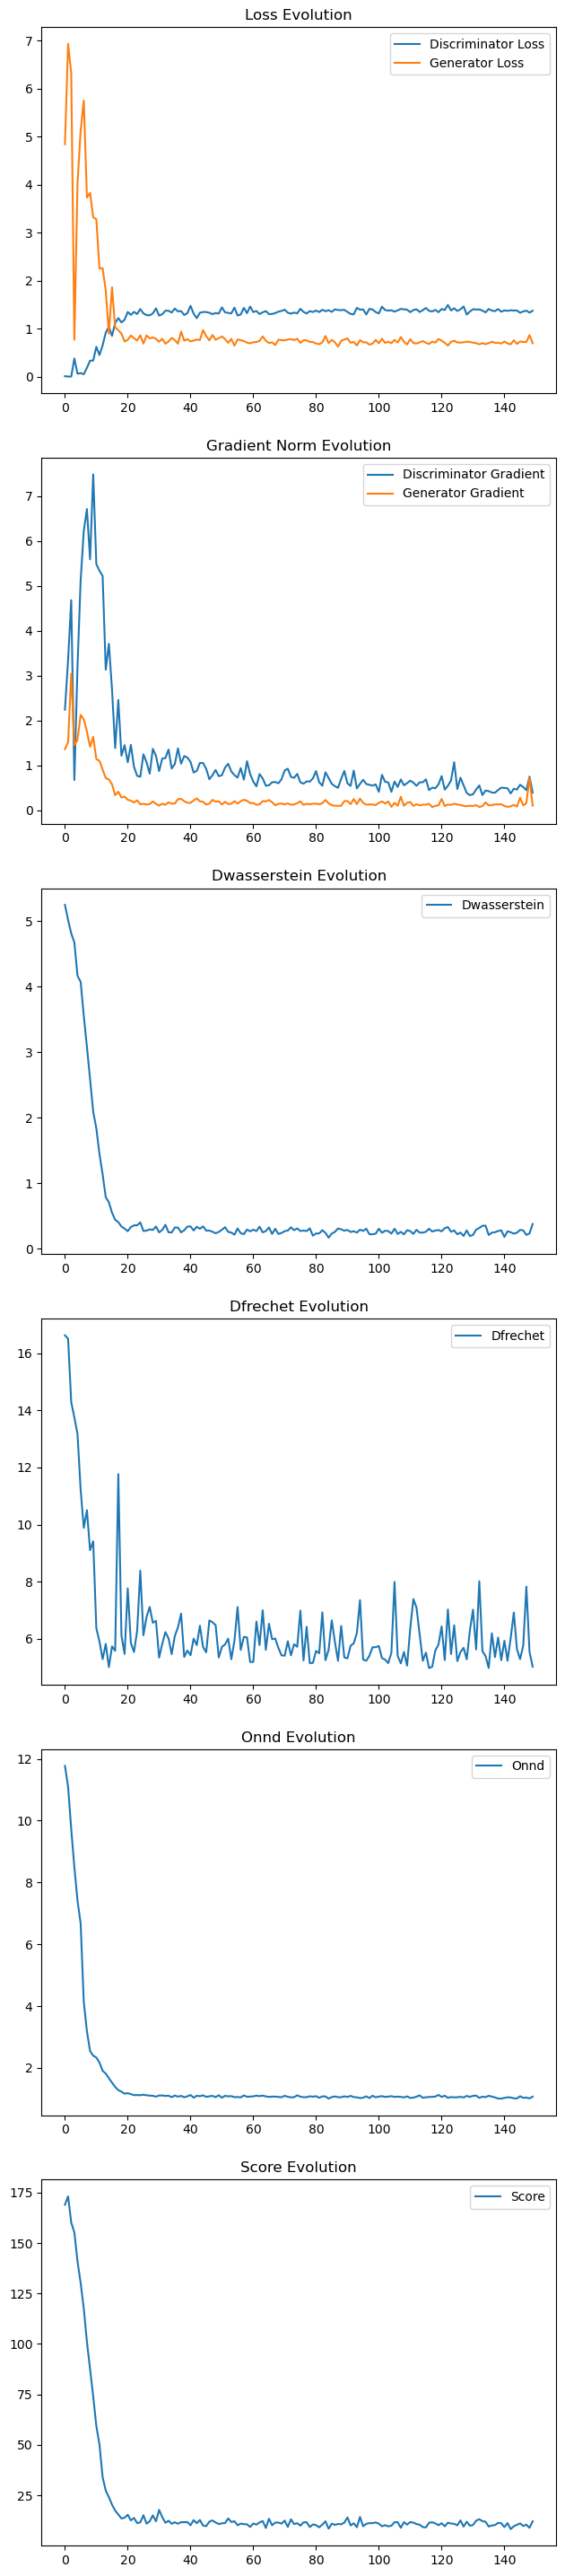

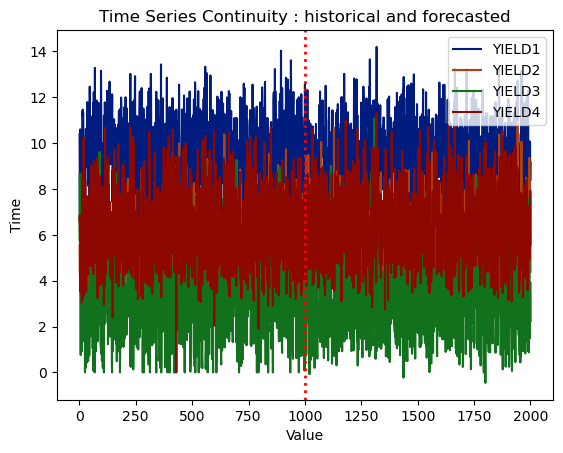

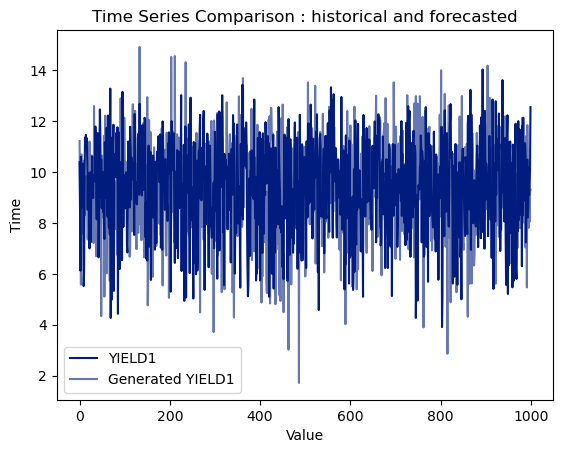

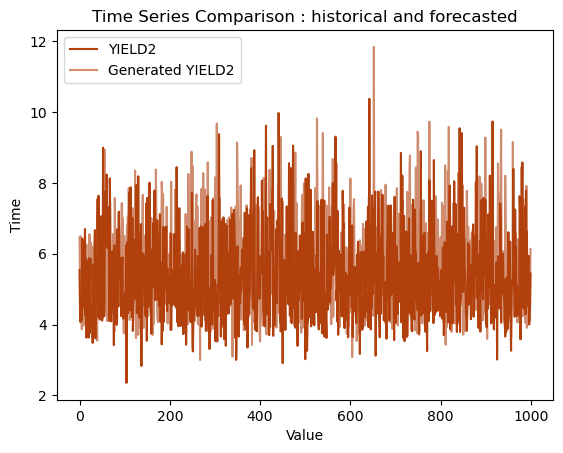

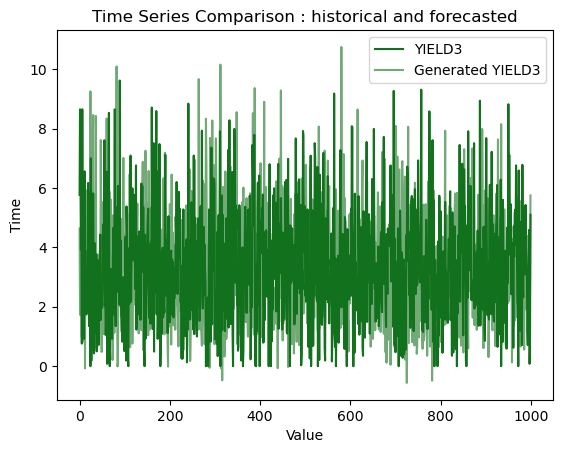

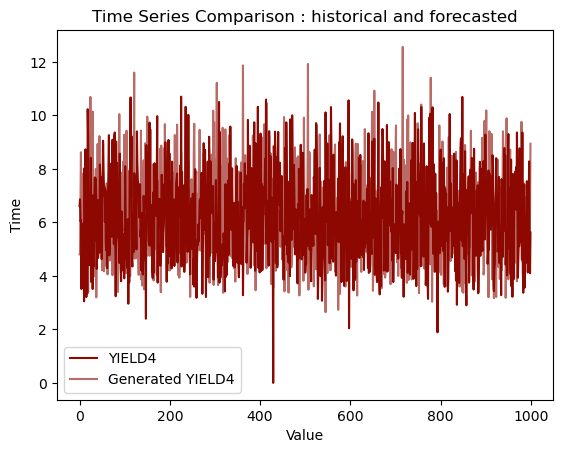

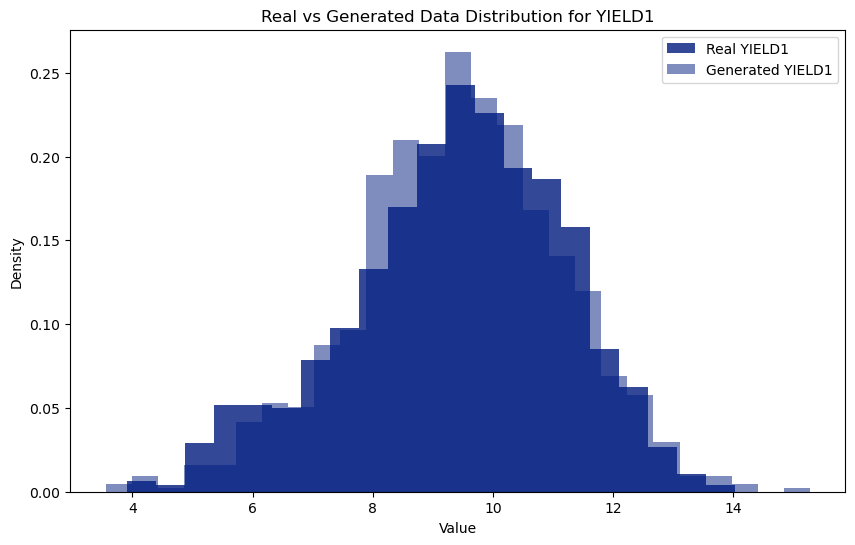

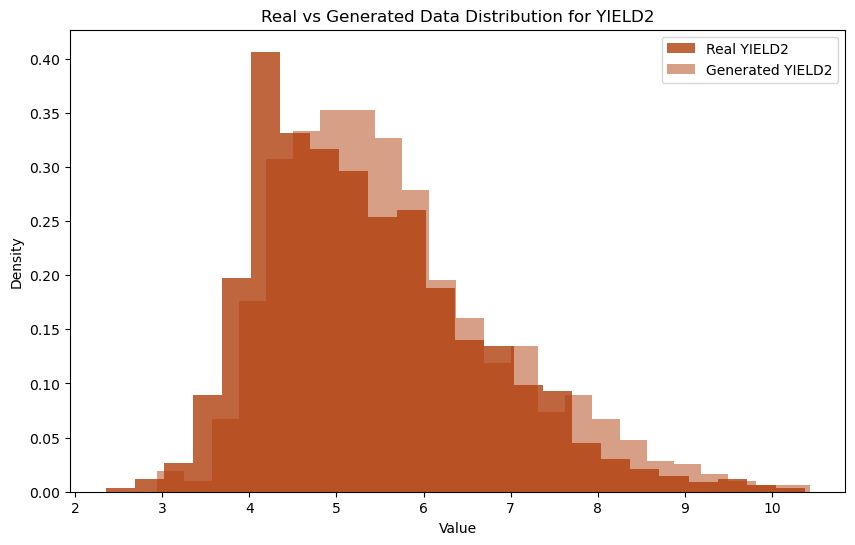

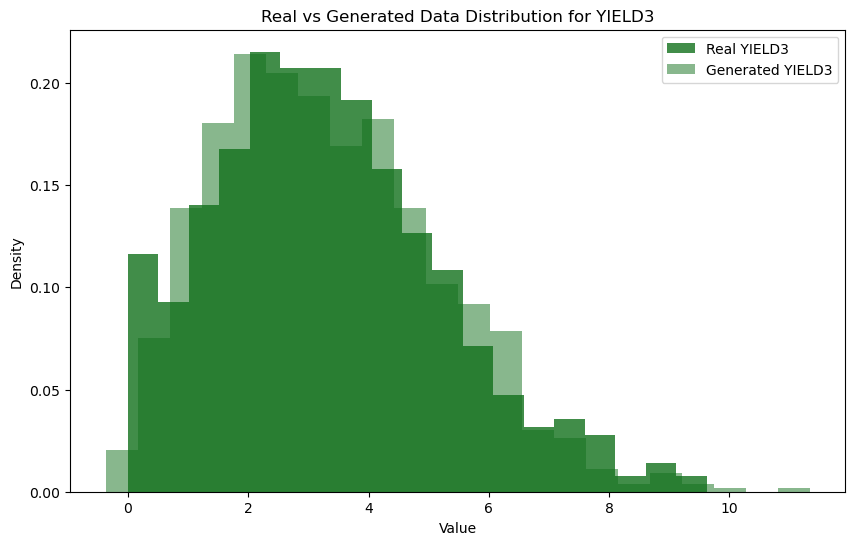

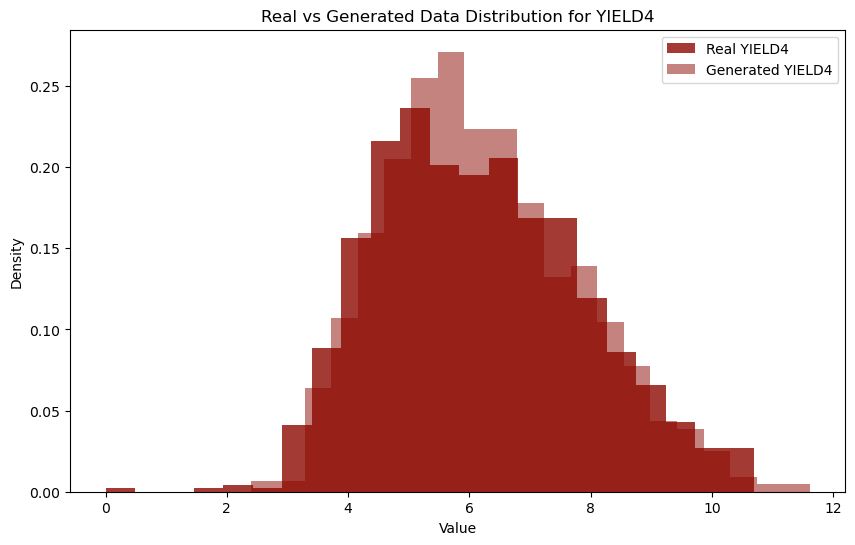

fit took 550.360619 seconds


{'dWasserstein': (0.12009193265146716, 0.27240596488278584),
 'dFrechet': (6.178975419788079, 5.275582410077509),
 'ONND': (0.7470925130334287, 1.0804320225999648),
 'score': (7.432690716939338, 9.302246705359845)}

In [57]:
model = GAN()
model.set_data(data)
model.set_metrics({'dWasserstein': {'function':dWasserstein, 'metric_args': {}}, 'dFrechet': {'function':dFrechet, 'metric_args': {}}, 'ONND': {'function':ONND, 'metric_args': {}}, 'score': {'function':score, 'metric_args': {}}})
model.fit(architectures = archi, params = params, verbose= True)

In [45]:
model.fit_hyperparameters({"lr_g": [5e-6, 5e-3], "lr_d": [5e-6, 5e-3], "epochs": [50, 150], "batch_size": [3,100], "latent_dim": [1,50]}, n_trials = 100)

[I 2025-04-22 15:36:36,066] A new study created in memory with name: no-name-099aa977-695a-4e36-948d-309347c830b4


fit took 50.444115 seconds


[I 2025-04-22 15:37:27,369] Trial 0 finished with value: 272.81761319574434 and parameters: {'lr_g': 0.003943203445688048, 'lr_d': 0.00494888022611325, 'epochs': 143, 'batch_size': 56, 'latent_dim': 7}. Best is trial 0 with value: 272.81761319574434.


fit took 30.181571 seconds


[I 2025-04-22 15:37:58,741] Trial 1 finished with value: 181.3761483567494 and parameters: {'lr_g': 0.0024254203246833785, 'lr_d': 0.004966697164830058, 'epochs': 80, 'batch_size': 18, 'latent_dim': 1}. Best is trial 1 with value: 181.3761483567494.


...

[I 2025-04-22 16:35:07,365] Trial 97 finished with value: 96.59515981225685 and parameters: {'lr_g': 0.00023324675687917345, 'lr_d': 0.0026696915596960196, 'epochs': 138, 'batch_size': 27, 'latent_dim': 47}. Best is trial 71 with value: 10.36690388266725.


fit took 47.315519 seconds


[I 2025-04-22 16:35:56,102] Trial 98 finished with value: 21.509501257457913 and parameters: {'lr_g': 0.00012163302800572692, 'lr_d': 0.0004438208916684613, 'epochs': 105, 'batch_size': 96, 'latent_dim': 42}. Best is trial 71 with value: 10.36690388266725.


fit took 46.822247 seconds


[I 2025-04-22 16:36:43,785] Trial 99 finished with value: 21.45967366889628 and parameters: {'lr_g': 0.0004037209494477293, 'lr_d': 0.0002643984541041565, 'epochs': 120, 'batch_size': 93, 'latent_dim': 29}. Best is trial 71 with value: 10.36690388266725.


In [46]:
print(model.parameters)

{'lr_g': 5.160837730712235e-05, 'lr_d': 0.0006435516339251255, 'epochs': 115, 'batch_size': 95, 'latent_dim': 42}


Epoch [1/115], C Loss: 0.5325, G Loss: 1.8005, 
Epoch [2/115], C Loss: 1.0914, G Loss: 1.8270, 
Epoch [3/115], C Loss: 1.1579, G Loss: 0.6902, 
Epoch [4/115], C Loss: 0.9413, G Loss: 0.5464, 
Epoch [5/115], C Loss: 1.7795, G Loss: 0.2794, 
Epoch [6/115], C Loss: 1.0587, G Loss: 0.5066, 
Epoch [7/115], C Loss: 1.0801, G Loss: 0.7000, 
Epoch [8/115], C Loss: 1.0836, G Loss: 0.7806, 
Epoch [9/115], C Loss: 1.1863, G Loss: 1.2542, 
Epoch [10/115], C Loss: 1.0344, G Loss: 0.7726, 
Epoch [11/115], C Loss: 1.1255, G Loss: 0.9282, 
Epoch [12/115], C Loss: 1.3483, G Loss: 0.6120, 
Epoch [13/115], C Loss: 1.2808, G Loss: 0.9241, 
Epoch [14/115], C Loss: 1.1597, G Loss: 0.8600, 
Epoch [15/115], C Loss: 1.4150, G Loss: 0.9610, 
Epoch [16/115], C Loss: 1.6645, G Loss: 1.1388, 
Epoch [17/115], C Loss: 1.3787, G Loss: 1.0372, 
Epoch [18/115], C Loss: 1.4203, G Loss: 0.8171, 
Epoch [19/115], C Loss: 1.3845, G Loss: 0.8928, 
Epoch [20/115], C Loss: 1.4466, G Loss: 0.7909, 
Epoch [21/115], C Loss: 1.454

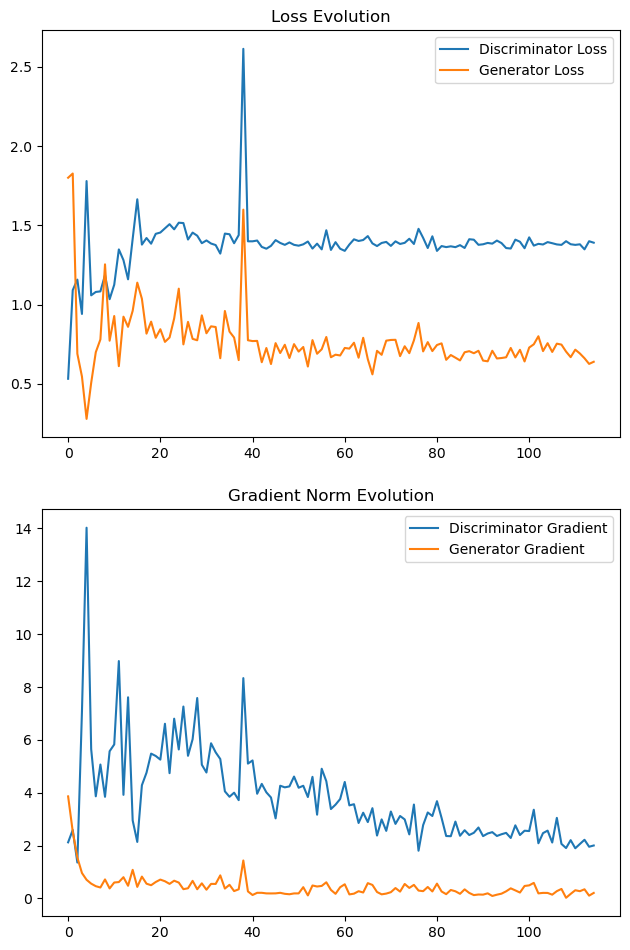

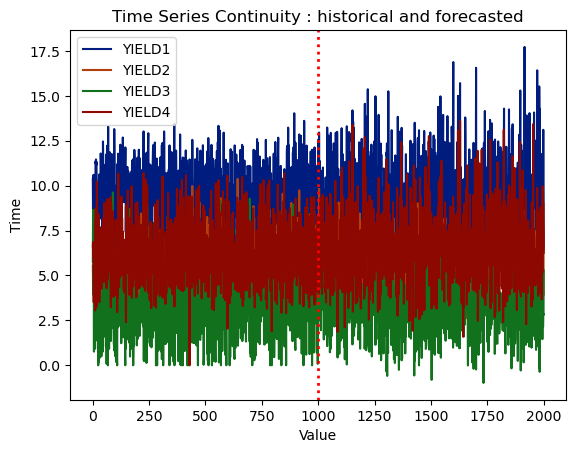

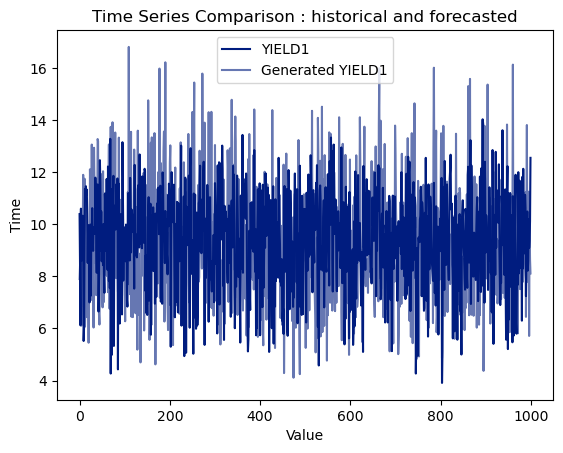

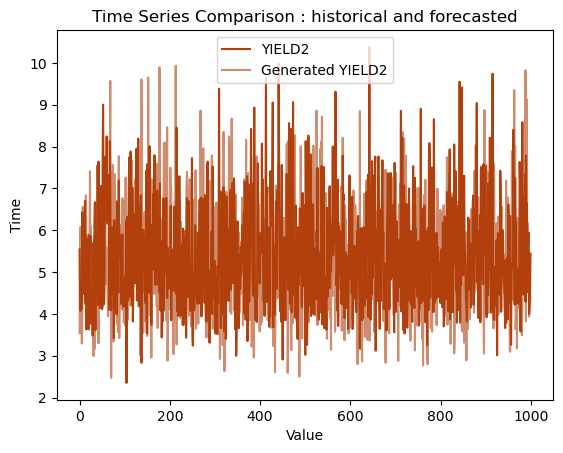

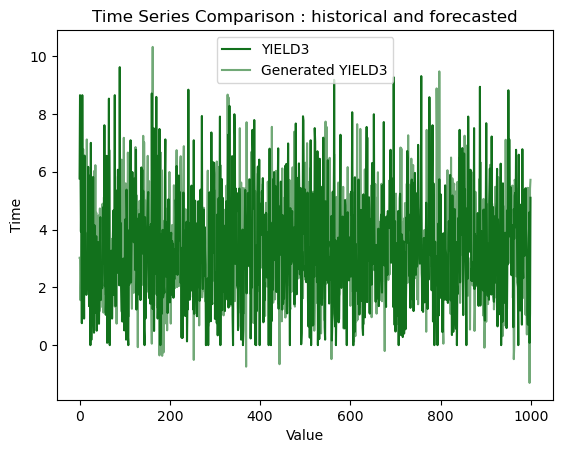

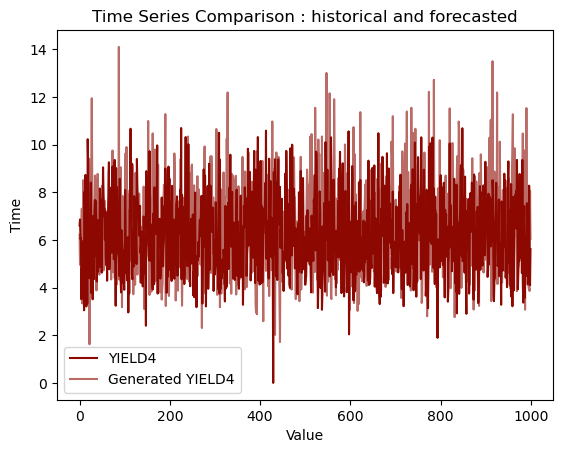

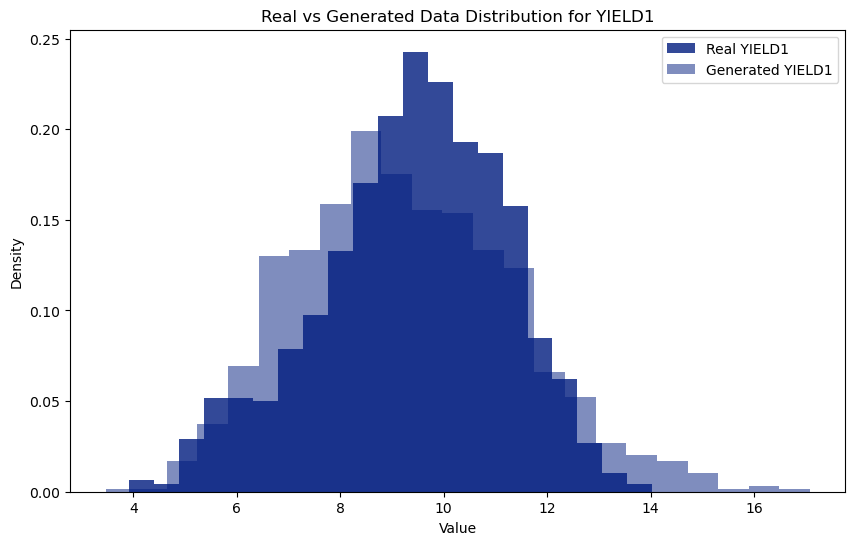

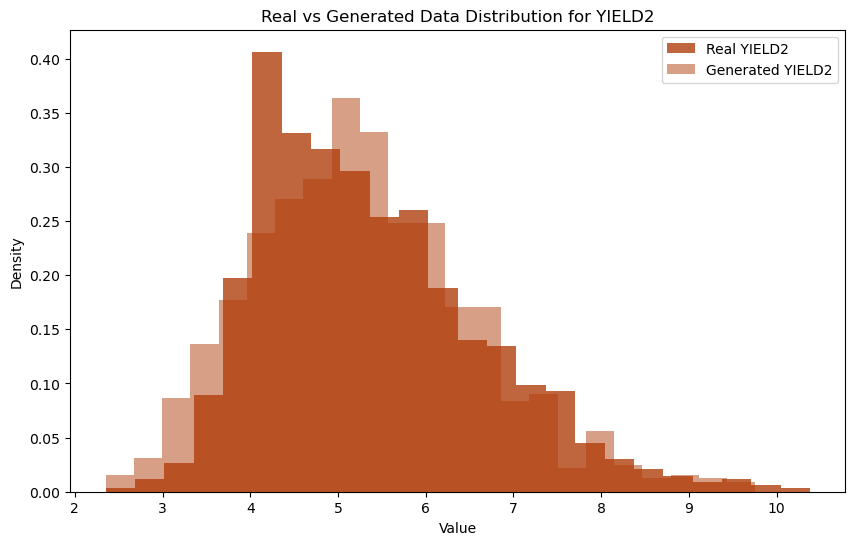

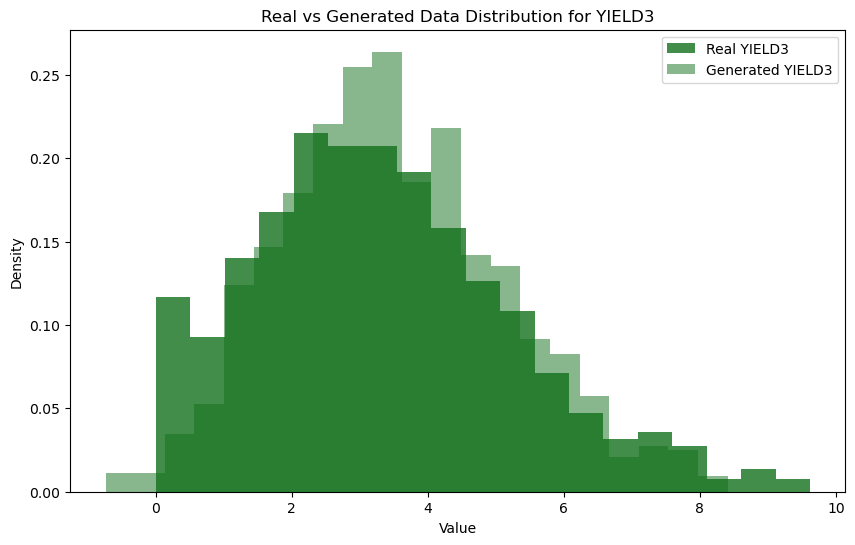

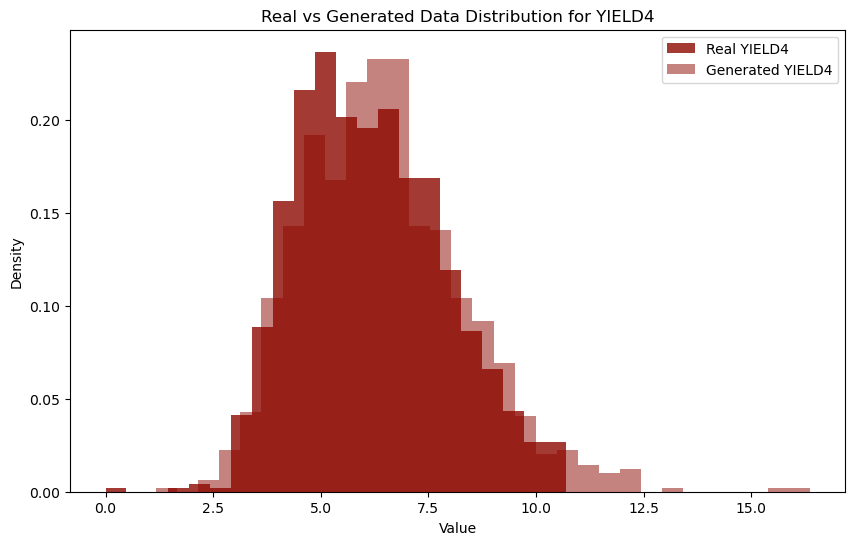

fit took 57.212901 seconds


{}

In [49]:
model.fit(verbose = True)

In [50]:
model.compute_val_metric(score)

16.91523812075297

In [54]:
n = 10

w = [model.compute_val_metric(dWasserstein, {}) for _ in range(n)]
f = [model.compute_val_metric(dFrechet, {}) for _ in range(n)]
o = [model.compute_val_metric(ONND, {}) for _ in range(n)]
s = [model.compute_val_metric(score, {}) for _ in range(n)]

print("Wasserstein", sum(w)/n)
print("Fréchet", sum(f)/n)
print("ONND", sum(o)/n)
print("Score", sum(s)/n)

Wasserstein 0.2502026050095061
Fréchet 8.142100732031517
ONND 1.0326946989139616
Score 11.05701866334497


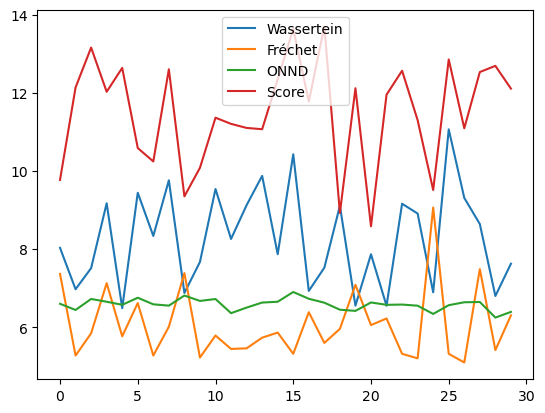

In [33]:
import matplotlib.pyplot as plt
plt.plot([30*x for x in w], label = "Wassertein")
plt.plot([x for x in f], label = "Fréchet")
plt.plot([np.power(len(model.train_data), 0.27)*x for x in o], label = "ONND")
plt.plot([x for x in s], label = "Score")
plt.legend()